# Entrenar modelo Client Churn - Optimización Optuna
- Modelo para predecir abandono de cliente
- Tipo de problema ML supervisado. Modelos a evaluar: Clasificación

- `pos_label`: Parámetro que indica cual etiqueta es tratada como positiva en clasificadores binarios (p.e. pos_label=1, pos_label='yes', pos_label='si', pos_label='positive'). Si es ignorada por defecto es 1. No aplica para clasificadores no binarios.
- Compatible con `Serverless compute`. Usa Optuna para optimización de hiperparámetros con scikit-learn.

## Optimización Optuna
<b>Definir objetivos/función de pérdida y espacio de busqueda a optimizar</b>
El espacio de busqueda es definido utilizanod funciones como: `suggest_categorical`, `suggest_float`, `suggest_int`  para el objeto Trial (ensayo) que es pasado a la función objetivo.

Documentación optuna:
* [optuna.samplers](https://optuna.readthedocs.io/en/stable/reference/samplers/index.html)
* [optuna.pruners](https://optuna.readthedocs.io/en/stable/reference/pruners.html)
* [optuna.integration.mlflow](https://optuna.readthedocs.io/en/stable/reference/generated/optuna.integration.mlflow.MLflowCallback.html)
* [Distribuir la optimización de hiperparámetros con Optuna, XGBoost, y MLflow](https://docs.databricks.com/en/machine-learning/automl-hyperparam-tuning/optuna-tutorial.html)

### Experimento MLflow con Optuna. Sabor: crear almacenamiento compartido para optimización distribuida
- MlflowStorage: Permite a MLflow actuar como base de datos backend para estudios Optuna
- MlflowSparkStudy: Envuelve ejecuciones en paralelo de estudios Optuna entre ejecutores Spark

###MLflowCallback (disponible en Optuna 4.8.0)
- Funciona con optuna.create_study() estándar. 
- Paralelización local. 
- Para experimentos pequeños/medianos
- Experimento crado en memoria.
- Limitaciones: No aprovecha el procesamiento distribuido de Spark. Los trials se ejecutan en un solo nodo

from optuna.integration.mlflow import MLflowCallback

mlflc = MLflowCallback(
    tracking_uri=mlflow.get_tracking_uri(),
    metric_name=metric_name,
    create_experiment=False # create_experiment=False es requerido en Databricks notebooks
)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100, callbacks=[mlflc])

## 1. Configuración

In [0]:
import sys
# Capturar versión de Python actual del sistema
python_version = f"{sys.version_info.major}.{sys.version_info.minor}.{sys.version_info.micro}"
print(f"Versión de Python actual: {python_version}")

Versión de Python actual: 3.12.3


In [0]:
# Instalar dependencias de Databricks
# %pip install --quiet databricks-automl-runtime
%pip install --quiet databricks-sdk>=0.102.0 databricks-feature-engineering --upgrade
%pip install --quiet mlflow --upgrade

# Instalar librerías de ML y procesamiento
%pip install --quiet scipy scikit-learn lightgbm xgboost 
%pip install --quiet imbalanced-learn category-encoders holidays
%pip install --quiet optuna

# Instalar librerías de visualización
# %pip install --quiet matplotlib seaborn

# Gráficos Optuna como artefactos de. IMPORTANTE: Usar Kaleido 0.2.1 (compatible con Plotly 5.9.0 de Databricks)
%pip install --quiet kaleido==0.2.1

dbutils.library.restartPython()

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
dbutils.widgets.removeAll()

In [0]:
catalog = "medallion_dev"
schema = "gold"
model_name = "customer_churn_classifier"

dbutils.widgets.text("model_full_name", f"{catalog}.{schema}.{model_name}", "Modelo nombre completo: catalog.schema.name") 
dbutils.widgets.text("project_path", "/Workspace/Proyectos_Dev/databricks-medallion", "Ruta del proyecto")
dbutils.widgets.text("n_trials", "10", "Número de trials de Optuna por modelo")
dbutils.widgets.text("n_jobs", "-1", "Número de jobs - ejecuciones paralelas")

In [0]:
model_full_name = dbutils.widgets.get("model_full_name")
project_path = dbutils.widgets.get("project_path")
n_trials = int(dbutils.widgets.get("n_trials"))
n_jobs = int(dbutils.widgets.get("n_jobs"))
catalog = model_full_name.split('.')[0]
schema = model_full_name.split('.')[1]
model_name = model_full_name.split('.')[-1]
feature_table_name = f"{catalog}.{schema}.churn_user_features"
target_col = "churn"
pos_label = 1

xp_name = model_name
xp_path = f"{project_path}/Experiments"
experiment_full_path = f"{xp_path}/{xp_name}"
run_name = target_col
model_alias_challenger = "challenger"
metric_score = "f1"
rng_seed = 42

In [0]:
try:
  from databricks.sdk import WorkspaceClient
  w = WorkspaceClient()
  r = w.workspace.mkdirs(path=xp_path)
except Exception as e:
  print(f"ERROR: No puedo crear folder para los experimentos: {xp_path} - Por favor cree la carpeta manualmente. Mensaje: {e}")
  raise e

## 2 Graficos Analisis exploratorio de datos (EDA) y de Metricas

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_target_distributions(pdf: pd.DataFrame, target_col: str) -> plt.Figure:
    """
    Creates a grid of histograms for each feature in the dataset.

    Args:
        pdf (: pd.DataFrame): DataFrame con los datos.
        target_col (str): Nombre de la columna objetivo
    Returns:
        plt.Figure: The matplotlib Figure object containing the plots.
    """
    pdf = pdf.groupby(target_col).size().reset_index(name="Contar")
    pdf["Porcentaje"] = pdf["Contar"] / total_count * 100
    pdf = pdf[[target_col, "Contar", "Porcentaje"]]
    
    labels = pdf[target_col].astype(str)
    sizes = pdf['Contar']

    fig, ax = plt.subplots(figsize=(4, 4))
    #plt.figure(figsize=(4, 4))
    plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
    plt.title('Distribución de la variable objetivo')
    plt.axis('equal')
    plt.close(fig)
    return fig

def plot_feature_distributions(X: pd.DataFrame, y: pd.Series, n_cols: int = 3) -> plt.Figure:
    """
    Creates a grid of histograms for each feature in the dataset.

    Args:
        X (pd.DataFrame): DataFrame containing synthetic features.
        y (pd.Series): Series containing the target variable.
        n_cols (int): Number of columns in the grid layout.

    Returns:
        plt.Figure: The matplotlib Figure object containing the distribution plots.
    """
    features = X.columns
    n_features = len(features)
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.flatten() if n_rows * n_cols > 1 else [axes]
    
    for i, feature in enumerate(features):
        if i < len(axes):
            ax = axes[i]
            sns.histplot(X[feature], ax=ax, kde=True, color='skyblue')
            ax.set_title(f'Distribucion de {feature}')
    
    # Hide any unused subplots
    for i in range(n_features, len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    fig.suptitle('Distribucion características', y=1.02, fontsize=16)
    plt.close(fig)
    return fig

def plot_correlation_heatmap(X: pd.DataFrame, y: pd.Series) -> plt.Figure:
    """
    Creates a correlation heatmap of all features and the target variable.

    Args:
        X (pd.DataFrame): DataFrame containing features.
        y (pd.Series): Series containing the target variable.

    Returns:
        plt.Figure: The matplotlib Figure object containing the heatmap.
    """
    # Combine features and target into one DataFrame
    data = X.copy()
    data['target'] = y
    
    # Calculate correlation matrix
    corr_matrix = data.corr()
    
    # Set up the figure
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Draw the heatmap with a color bar
    cmap = sns.diverging_palette(220, 10, as_cmap=True)
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap=cmap,
                center=0, square=True, linewidths=0.5, ax=ax)
    
    ax.set_title('Mapa de calor (Heatmap) de correlación de caracteristicas', fontsize=16)
    plt.close(fig)
    return fig

def plot_feature_target_relationships(X: pd.DataFrame, y: pd.Series, n_cols: int = 3) -> plt.Figure:
    """
    Creates a grid of scatter plots showing the relationship between each feature and the target.

    Args:
        X (pd.DataFrame): DataFrame containing features.
        y (pd.Series): Series containing the target variable.
        n_cols (int): Number of columns in the grid layout.

    Returns:
        plt.Figure: The matplotlib Figure object containing the relationship plots.
    """
    features = X.columns
    n_features = len(features)
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.flatten() if n_rows * n_cols > 1 else [axes]
    
    for i, feature in enumerate(features):
        if i < len(axes):
            ax = axes[i]
            # Scatter plot with regression line
            sns.regplot(x=X[feature], y=y, ax=ax, 
                       scatter_kws={'alpha': 0.5, 'color': 'blue'}, 
                       line_kws={'color': 'red'})
            ax.set_title(f'{feature} vs Target')
    
    for i in range(n_features, len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    fig.suptitle('Relación caracteristicas vs Objetivo', y=1.02, fontsize=16)
    plt.close(fig)
    return fig

def plot_pairwise_relationships(X: pd.DataFrame, y: pd.Series, features: list[str]) -> plt.Figure:
    """
    Creates a pairplot showing relationships between selected features and the target.

    Args:
        X (pd.DataFrame): DataFrame containing features.
        y (pd.Series): Series containing the target variable.
        features (List[str]): List of feature names to include in the plot.

    Returns:
        plt.Figure: The matplotlib Figure object containing the pairplot.
    """
    # Ensure features exist in the DataFrame
    valid_features = [f for f in features if f in X.columns]
    
    if not valid_features:
        fig, ax = plt.subplots()
        ax.text(0.5, 0.5, "Caracteristicas no validas", ha='center', va='center')
        return fig
    
    # Combine selected features and target
    data = X[valid_features].copy()
    data['target'] = y
    
    # Create pairplot
    pairgrid = sns.pairplot(data, diag_kind="kde", 
                          plot_kws={"alpha": 0.6, "s": 50},
                          corner=True)
    
    pairgrid.fig.suptitle("Relación caracteristicas po pares", y=1.02, fontsize=16)
    plt.close(pairgrid.fig)
    return pairgrid.fig

def plot_boxplots(X: pd.DataFrame, y: pd.Series, n_cols: int = 3) -> plt.Figure:
    """
    Creates a grid of box plots for each feature, with points colored by target value.

    Args:
        X (pd.DataFrame): DataFrame containing features.
        y (pd.Series): Series containing the target variable.
        n_cols (int): Number of columns in the grid layout.

    Returns:
        plt.Figure: The matplotlib Figure object containing the box plots.
    """
    features = X.columns
    n_features = len(features)
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.flatten() if n_rows * n_cols > 1 else [axes]
    
    # Create target bins for coloring
    y_binned = pd.qcut(y, 3, labels=['Low', 'Medium', 'High'])
    
    for i, feature in enumerate(features):
        if i < len(axes):
            ax = axes[i]
            # Box plot for each feature
            sns.boxplot(x=y_binned, y=X[feature], ax=ax)
            ax.set_title(f'Distribución de {feature} por rango Objetivo')
            ax.set_xlabel('Rango Objetivo')
    
    # Hide any unused subplots
    for i in range(n_features, len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    fig.suptitle('Distribucion de caracteristicas por rango objetivo', y=1.02, fontsize=16)
    plt.close(fig)
    return fig

def plot_outliers(X: pd.DataFrame, n_cols: int = 3) -> plt.Figure:
    """
    Creates a grid of box plots to detect outliers in each feature.

    Args:
        X (pd.DataFrame): DataFrame containing features.
        n_cols (int): Number of columns in the grid layout.

    Returns:
        plt.Figure: The matplotlib Figure object containing the outlier plots.
    """
    features = X.columns
    n_features = len(features)
    n_rows = (n_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.flatten() if n_rows * n_cols > 1 else [axes]
    
    for i, feature in enumerate(features):
        if i < len(axes):
            ax = axes[i]
            # Box plot to detect outliers
            sns.boxplot(x=X[feature], ax=ax, color='skyblue')
            ax.set_title(f'Deteccion de anomalías pra {feature}')
            ax.set_xlabel(feature)
    
    # Hide any unused subplots
    for i in range(n_features, len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    fig.suptitle('Deteccion de anomalizas por caracteristicas', y=1.02, fontsize=16)
    plt.close(fig)
    return fig

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

def plot_confusion_matrix(y_test: pd.Series, y_pred: pd.Series, model_name: str, target_col: str) -> plt.Figure:
    """
    Crea grafico matriz de confusión.

    Args:
        y_test (pd.Series): Serie contine variable objetivo de prueba
        y_pred (pd.Series): Serie contine variable objetivo con predicciones realizadas por el modelo
        model_name (str): Nombre del modelo para predecir los datos
        target_col (str): Nombre de la columna objetivo
    Returns:
        plt.Figure: The matplotlib Figure object containing the plots.
    """
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f'No {target_col}', target_col])

    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    plt.title(f'Matriz de Confusión - {model_name}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.close(fig)
    return fig


def plot_ROC_curve(y_test: pd.Series, y_pred_proba: pd.Series, model_name: str) -> plt.Figure:
    """
    Crea grafico curva ROC.

    Args:
        y_test (pd.Series): Serie contine variable objetivo de prueba
        y_pred_proba (pd.Series): Serie contine variable objetivo con probabilidad de predicción realizadas por el modelo
        model_name (str): Nombre del modelo para predecir los datos
    Returns:
        plt.Figure: The matplotlib Figure object containing the plots.
    """
    # Calcular curva ROC
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.4f})')
    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random clasificador')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('Falsos Positivos (%)', fontsize=12)
    ax.set_ylabel('Verdaderos Positivos (%)', fontsize=12)
    ax.set_title(f'Curva ROC - {model_name}', fontsize=14, fontweight='bold')
    ax.legend(loc="lower right", fontsize=10)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.close(fig)
    return fig


def plot_compare_scores(optimization_results, best_results, metric_score: str) -> plt.Figure:
    """
    Crea grafico para comparar modelos con los resultados de optimización Optuna y resultados de mejores modelos.

    Args:
        optimization_results: Arreglo con el resultado de la metrica de validacón usando Optuna
        best_results: Arreglo con el resultado de la metrica de validacón usando los mejores modelos 
        metric_score (str): Metrica de validacion de los modelos
    Returns:
        plt.Figure: The matplotlib Figure object containing the plots.
    """
    # Comparar scores de validación (Optuna) vs test final
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Gráfico 1: durante optimización (validación)
    opt_scores = [r['Best_Score'] for r in optimization_results]
    model_names = [r['Model'] for r in optimization_results]
    ax1.barh(model_names, opt_scores, color='steelblue')
    ax1.set_xlabel(f'{metric_score} Score', fontsize=11)
    ax1.set_title(f'Mejor {metric_score} Score - Validación Optuna', fontsize=12, fontweight='bold')
    ax1.set_xlim([0, 1])
    for i, v in enumerate(opt_scores):
        ax1.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

    # Gráfico 2: final en test
    test_scores = [r[metric_score] for r in best_results]
    test_model_names = [r['Model'] for r in best_results]
    ax2.barh(test_model_names, test_scores, color='darkorange')
    ax2.set_xlabel(f'{metric_score} Score', fontsize=11)
    ax2.set_title(f'Mejor {metric_score} Score - Conjunto de datos Test', fontsize=12, fontweight='bold')
    ax2.set_xlim([0, 1])
    for i, v in enumerate(test_scores):
        ax2.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

    plt.tight_layout()
    plt.close(fig)
    return fig

## 3. Conjuntos de datos y Características

Peso clases desbalacneadas negativos/positivos: 0.5243419254941252

Distribución de la variable objetivo 'churn':


churn,Contar,Porcentaje
0,23027,34.3979206190341
1,43916,65.60207938096589


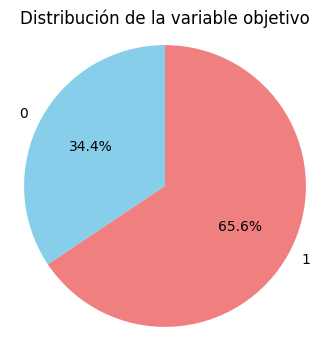

In [0]:
df = spark.table(feature_table_name) 

# Calcular peso para clases desbalanceadas
total_count = df.count()
pos = df.filter(f"{target_col} = {pos_label}").count()
neg = total_count - pos
scale_pos_weight = neg / pos
print(f"Peso clases desbalacneadas negativos/positivos: {scale_pos_weight}") 

print(f"\nDistribución de la variable objetivo '{target_col}':")
temp_df = df.groupBy(target_col).count().withColumnRenamed("count", "Contar")
temp_df = temp_df.withColumn("Porcentaje", (temp_df["Contar"] / total_count) * 100)
display(temp_df.orderBy(target_col))

tmp_plot = plot_target_distributions(df.toPandas(), target_col)
display(tmp_plot)

### Dividir los datos

#### Series de tiempo
Si la tabla de caracteristicas tiene una columna de tiempo puede dividir los datos en: entrenamiento datos pasados y test nuevos datos:

df = spark.table('travel_purchase').select('user_id', 'destination_id', 'purchased', 'ts').sample(fraction=0.3, seed=42)

training_df = df.filter(F.col('ts') < datetime(2023, 1, 1))
test_df = df.filter(F.col('ts') >= datetime(2023, 1, 1))

### Seleccionar columnas entrenamiento
Seleccionar solo las columnas para entrenar el modelo.

In [0]:
from sklearn.base import BaseEstimator, TransformerMixin

class CustomColumnSelector(BaseEstimator, TransformerMixin):
    """Selector de columnas que mantiene el formato DataFrame. Para resolver error:
    El ColumnTransformer convertía el DataFrame a numpy array, pero al ensamblar pipeline es necesario nombres de columnas.
    
    Ejemplo 1: Para Serverless, cuando no funciona el ejemplo 2
    from sklearn.compose import ColumnTransformer
    column_selector = ColumnTransformer(transformers=[("selector", "passthrough", supported_cols)])
    
    Ejemplo 2:
    from databricks.automl_runtime.sklearn.column_selector import ColumnSelector
    column_selector = ColumnSelector(supported_cols)    
    """
    def __init__(self, columns):
        self.columns = columns
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        return X[self.columns]

In [0]:
supported_cols = ["gender", "last_transaction", "canal", "event_count", "days_since_creation", "country", "session_count",
    "order_count", "days_last_event", "days_since_last_activity",
    "total_amount", "total_item", "age_group", "platform"
]
df = df.select(*supported_cols, target_col)
print(f"Columnas soportadas: {supported_cols}")
display(df.limit(5))

# Selector de columnas
column_selector = CustomColumnSelector(supported_cols)

train_df, test_df = df.randomSplit([0.8, 0.2], seed=rng_seed)

# X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(df.toPandas(), df[target_col].toPandas(), test_size=0.2, random_state=rng_seed)

Columnas soportadas: ['gender', 'last_transaction', 'canal', 'event_count', 'days_since_creation', 'country', 'session_count', 'order_count', 'days_last_event', 'days_since_last_activity', 'total_amount', 'total_item', 'age_group', 'platform']


gender,last_transaction,canal,event_count,days_since_creation,country,session_count,order_count,days_last_event,days_since_last_activity,total_amount,total_item,age_group,platform,churn
0,2023-06-05T06:23:07.000Z,PHONE,4,1185,SPAIN,3,4,1039,1039,223,9,4,ios,1
1,2023-06-09T06:33:02.000Z,MOBILE,6,1140,FR,5,6,1039,1036,247,10,1,android,0
1,2023-06-08T02:08:17.000Z,PHONE,1,1377,USA,0,1,1041,1043,96,3,5,other,1
1,2023-06-09T18:28:14.000Z,MOBILE,4,1559,USA,3,4,1036,1039,191,7,7,other,1
1,2023-06-08T21:50:54.000Z,WEBAPP,2,1489,SPAIN,1,2,1038,1041,103,5,5,ios,0


In [0]:
from sklearn.model_selection import train_test_split

# Feacture Lookup (fe.create_training_set) no funciona en cluster Serverless
from databricks.feature_engineering import FeatureEngineeringClient, FeatureLookup
use_feactures = False

# Convertir a pandas para scikit-learn y Dividir en validación para Optuna
if use_feactures:
    fe = FeatureEngineeringClient()

    model_feature_lookups = [
        FeatureLookup(
            table_name=feature_table_name,
            lookup_key="user_id",
            feature_names=supported_cols 
        )
    ]

    # will look up features with matched key. Exclude id columns as we don't want them as feature
    train_set = fe.create_training_set(df=train_df, feature_lookups=model_feature_lookups, label=target_col,
        exclude_columns=["ingest_datetime_silver", "user_id"])
    test_set = fe.create_training_set(df=test_df, feature_lookups=model_feature_lookups, label=target_col,
        exclude_columns=["ingest_datetime_silver", "user_id"])
    
    train_pdf = train_set.load_df().toPandas()
    test_pdf = test_set.load_df().toPandas()
else:
    train_pdf = train_df.toPandas()
    test_pdf = test_df.toPandas()

train_opt_pdf, val_opt_pdf = train_test_split(train_pdf, test_size=0.2, random_state=rng_seed, stratify=train_pdf[target_col])

In [0]:
split_col = None

# Separate target column from features and drop
drop_cols = [target_col]
if split_col in train_opt_pdf.columns:
    drop_cols.append(split_col)

X_train = train_opt_pdf.drop(drop_cols, axis=1)
y_train = train_opt_pdf[target_col]

X_val = val_opt_pdf.drop(drop_cols, axis=1)
y_val = val_opt_pdf[target_col]

X_test = test_pdf.drop(drop_cols, axis=1)
y_test = test_pdf[target_col]

## 4. Preprocesamiento de datos

In [0]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Identificar columnas 
display(X_train.info())

categorical_cols = X_train.select_dtypes(include=['object', 'string']).columns.tolist()
numeric_cols = X_train.select_dtypes(include=['int32', 'int64', 'float64', 'double', 'byte', 'short', 'int']).columns.tolist() 
datetime_cols = X_train.select_dtypes(include=['datetime64']).columns.tolist() 
bool_cols = X_train.select_dtypes(include=['boolean']).columns.tolist()

numeric_cols.remove('gender')
bool_cols.append('gender')
categorical_cols.append('age_group')
categorical_cols.append('event_count')
categorical_cols.append('order_count')
categorical_cols.append('session_count')

print(f"\nColumnas booleanas: {bool_cols}")
print(f"Columnas tiempo: {datetime_cols}")
print(f"Columnas numéricas: {numeric_cols}")
print(f"Columnas categóricas: {categorical_cols}")

# Calcular class weight para XGBoost
scale_pos_weight = len(y_train[y_train==0])/len(y_train[y_train==1])
print(f"\nPeso de la escala positiva negativos/positivos: {scale_pos_weight:.2f}")

<class 'pandas.core.frame.DataFrame'>
Index: 42737 entries, 23170 to 44735
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   gender                    42737 non-null  int32         
 1   last_transaction          42737 non-null  datetime64[ns]
 2   canal                     42737 non-null  object        
 3   event_count               42737 non-null  int64         
 4   days_since_creation       42737 non-null  int32         
 5   country                   42737 non-null  object        
 6   session_count             42737 non-null  int64         
 7   order_count               42737 non-null  int64         
 8   days_last_event           42737 non-null  int32         
 9   days_since_last_activity  42737 non-null  int32         
 10  total_amount              42737 non-null  int64         
 11  total_item                42737 non-null  int64         
 12  age_group          

### Columnas datetime preproceso
**Prompt AI:**

Contexto: 
Entrenamiento de modelo ML utilizando la tabla de caracteristicas: medallion_dev.gold.churn_user_features".

Objetivo:
Preprocesamiento de columnas datatime: last_transaction y ingest_datetime_silver.

Reglas:
- Extraer información relevante de la fecha como cuando el día es normal o fin de semana
- Hora del día con one-hot-encoded
- Utilizar el transformador TimestampTransformer
- imputar datos con DatetimeImputer
- Estandarizar los datos con StandardScaler
 
Modo de trabajo:
- Realizar un ciclo con las columnas a transformar
- Agregar un sufijo a nombre del pipeline para hacerlo unico

In [0]:
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np

# datetime_cols = ["last_transaction"]

def convert_to_timestamp(X):
    """Convierte datetime a timestamp numérico para imputación.
       Manejar tanto DataFrame como numpy array"""
    if isinstance(X, np.ndarray):
        dt_col = pd.to_datetime(X[:, 0], errors='coerce')
    else:
        dt_col = pd.to_datetime(X.iloc[:, 0], errors='coerce')
    
    # Convertir a timestamp (segundos desde epoch)
    timestamps = dt_col.astype('int64') / 10**9
    return timestamps.to_frame()

def timestamp_to_datetime_features(X):
    """Convierte timestamp numérico de vuelta a datetime y extrae características"""
    # SimpleImputer devuelve numpy array
    if isinstance(X, np.ndarray):
        timestamps = X[:, 0]
    else:
        timestamps = X.iloc[:, 0]
    
    # Convertir de segundos a datetime (devuelve DatetimeIndex)
    dt_col = pd.to_datetime(timestamps, unit='s', errors='coerce')
    
    # DatetimeIndex ya tiene las propiedades directamente, sin .dt
    features = pd.DataFrame({
        'hour': dt_col.hour,
        'day_of_week': dt_col.dayofweek,
        'is_weekend': (dt_col.dayofweek >= 5).astype(int)
    })
    return features

datetime_transformers = []
for col in datetime_cols:
    timestamp_pipeline = Pipeline(steps=[
        (f"{col}_to_timestamp", FunctionTransformer(convert_to_timestamp, validate=False)),
        (f"{col}_imputer", SimpleImputer(strategy="mean")),
        (f"{col}_features", FunctionTransformer(timestamp_to_datetime_features, validate=False)),
        (f"{col}_scaler", StandardScaler()),
    ])
    datetime_transformers.append((f"{col}_pipeline", timestamp_pipeline, [col]))

### Columnas booleanas preproceso
**Prompt para transformar columnas boolean con AI:**
Contexto: 
Entrenamiento de modelo ML utilizando la tabla de características: medallion_dev.gold.churn_user_features".

Objetivo:
Preprocesamiento de columnas boolean: gender y churn.

Reglas:
- Convertir datos en tipo de datos entero.
- Imputar valores ausentes con el valor más comun.
- One-hot-encoding para crear columnas binarias 0|1. Quitar la primer columna para evitar multicolinealidad

In [0]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder as SklearnOneHotEncoder

# bool_cols = ["gender"]
bool_transformers = []

for col in bool_cols:
    bool_pipeline = Pipeline(steps=[
        (f"{col}_cast_type", FunctionTransformer(lambda df: df.astype(object))),
        (f"{col}_imputer", SimpleImputer(strategy="most_frequent")),
        (f"{col}_encoder", SklearnOneHotEncoder(handle_unknown="ignore", drop="first")),
    ])
    bool_transformers.append((f"{col}_pipeline", bool_pipeline, [col]))

### Columnas numéricas preproceso
**Prompt AI:**

Prompt para transformar columnas numericas con AI:
Contexto: 
Entrenamiento de modelo ML utilizando la tabla de características: medallion_dev.gold.churn_user_features".

Objetivo:
Preprocesamiento de columnas numericas: "age_group", "days_last_event", "days_since_creation", "days_since_last_activity", "event_count", "order_count", "session_count", "total_amount", "total_item".

Reglas:
- Convertir a tipo numérico datos
- Imputar valores ausentes a la media
- Estandarizar los datos

In [0]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.compose import ColumnTransformer

# numeric_cols = ["age_group", "days_last_event", "days_since_creation", "days_since_last_activity", "event_count", "order_count", "session_count", "total_amount", "total_item"]

numerical_transformers = [("numerical", Pipeline(steps=[
    ("to_numeric", FunctionTransformer(lambda x: x.apply(lambda col: pd.to_numeric(col, errors='coerce')))),
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
]), numeric_cols)]

### Columnas categóricas preproceso

#### Columnas categóricas de baja cardinalidad
Convertir en columnas binarias a través de one-hot encoding. Para cada columna categórica (texto o numérica), el número de columnas de salida es igual al número de valores únicos menos uno. Si hay valores ausentes en una columna, se ignoran durante el entrenamiento y se rellenan con ceros durante la inferencia.

In [0]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# categorical_cols = ["age_group", "canal", "country", "event_count", "order_count", "platform", "session_count"]

# One-Hot Encoding para categorías nuevas: 'warn': Advertencia y tratar como 'infrequent_if_exist'
categorical_low_transformers = [("onehot", Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="warn", sparse_output=False))
]), categorical_cols)]

#### Unir todos los transformadores

**Prompt para unir todos los transformadores con AI:**

Contexto: 
Entrenamiento de modelo ML utilizando la tabla de características: medallion_dev.gold.churn_user_features".

Objetivo:
Preprocessor para unir los transformadores datetime_transformers, bool_transformers, numerical_transformers, categorical_low_transformers.

Reglas:
- Usar ColumnTransformer para unir los transformadores
- Usar remainder="passthrough" para mantener las columnas no especificadas
- sparse_threshold=0 generar matriz densa (no sparse)

In [0]:
from sklearn.compose import ColumnTransformer

transformers = datetime_transformers + bool_transformers + numerical_transformers + categorical_low_transformers
preprocessor = ColumnTransformer(transformers,
    remainder="passthrough",  # Mantener columnas no especificadas
    sparse_threshold=0  # Generar matriz densa en lugar de sparse
)

## 5. Optimización de Hiperparámetros con Optuna

In [0]:
import optuna
from optuna.pruners import BasePruner
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, roc_auc_score
import mlflow
import mlflow.sklearn
from mlflow.models.signature import infer_signature
import random

# Suprimir warnings de Optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

### Funcion objetivo Optuna

In [0]:
def objective_LGBMClassifier(trial):
    """Optimizar LGBM Classifier"""
    params = {
		'n_estimators': trial.suggest_int('n_estimators', 50, 300, step=50),
		'max_depth': trial.suggest_int('max_depth', 3, 10),
		'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
		'num_leaves': trial.suggest_int('num_leaves', 20, 100),
		'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
		'random_state': rng_seed,
		'verbose': -1
    }
    
    pipeline = Pipeline([
        ('column_selector', column_selector),
        ('preprocessor', preprocessor),
        ('classifier', LGBMClassifier(**params))
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_val)
    return f1_score(y_val, y_pred, pos_label=pos_label)

def objetive_LogisticRegression(trial):
    """Optimizar LogisticRegression"""
    solver = trial.suggest_categorical('solver', ['lbfgs', 'liblinear', 'saga', 'newton-cg'])
    
    # Configurar penalty según el solver elegido (Depreciado)
    # lbfgs: solo acepta 'l2' o None
    # liblinear: acepta 'l1' o 'l2'
    # saga: acepta 'l1', 'l2', 'elasticnet', o None
    
    # 0 <= l1_ratio <= 1. l1_ratio=1 gives a pure L1-penalty, l1_ratio=0 a pure L2-penalty. 
    # Any value between 0 and 1 gives an Elastic-Net penalty of the form l1_ratio * L1 + (1 - l1_ratio) * L2.
    #l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0, step=0.10)

    if solver == 'lbfgs':
        l1_ratio = 0
        penalty = 'l2'
    elif solver == 'liblinear':
        num = random.randint(0, 1)
        if num == 0:
            l1_ratio = 0
            penalty = 'l2'
        else:
            l1_ratio = 1
            penalty = 'l1'
    elif solver == 'saga':
        num = random.randint(0, 10)/10
        if num == 0:
            l1_ratio = 0
            penalty = 'l2'
        elif num == 1:
            l1_ratio = 1
            penalty = 'l1'
        else:
            l1_ratio = num
            penalty = 'elasticnet'
    else: # 'newton-cg'
        l1_ratio = 0
        penalty = 'l2'

    # Por simplificar
    penalty: trial.suggest_categorical("penalty", ['l2'])
    l1_ratio = trial.suggest_float('l1_ratio', 0.0, 0.0)

    params = {
        'C': trial.suggest_float('C', 0.001, 10.0, log=True),
        'solver': solver,
        'l1_ratio': l1_ratio,
        'penalty': penalty,
        'max_iter': trial.suggest_int('max_iter', 100, 1000, step=100),
        'random_state': rng_seed,
        'class_weight': 'balanced'
    }
    
    try:
        pipeline = Pipeline([
            ('column_selector', column_selector),
            ('preprocessor', preprocessor),
            ('classifier', LogisticRegression(**params))
        ])
        
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_val)
        return f1_score(y_val, y_pred, pos_label=pos_label)
    except ValueError as e:
        print(f"Error en objetive_LogisticRegression: {e}")
        return None

def objetive_RandomForestClassifier(trial):
    """Optimizar RandomForest"""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'random_state': rng_seed,
        'class_weight': 'balanced'
    }
    
    pipeline = Pipeline([
        ('column_selector', column_selector),
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(**params))
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_val)
    return f1_score(y_val, y_pred, pos_label=pos_label)

def objetive_GradientBoostingClassifier(trial):
    """Optimizar GradientBoosting"""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'random_state': rng_seed
    }
    
    pipeline = Pipeline([
        ('column_selector', column_selector),
        ('preprocessor', preprocessor),
        ('classifier', GradientBoostingClassifier(**params))
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_val)
    return f1_score(y_val, y_pred, pos_label=pos_label)

def objetive_XGBClassifier(trial):
    """Optimizar XGBoost"""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 1.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 1.0),
        'random_state': rng_seed,
        'scale_pos_weight': scale_pos_weight
    }
    
    pipeline = Pipeline([
        ('column_selector', column_selector),
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(**params))
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_val)
    return f1_score(y_val, y_pred, pos_label=pos_label)

In [0]:
class NoneValueOptunaPruner(BasePruner):
    """
    Pruner personalizado de Optuna para eliminar trials con valores None.
    
    Esta clase hereda de BasePruner y proporciona una estrategia de poda simple
    que elimina trials que no produjeron un valor válido (None o vacío).
    Útil para limpiar trials fallidos durante la optimización.
    """
    
    def prune(self, study, trial):
        """
        Determina si un trial debe ser podado (eliminado) basándose en su valor.
        
        Args:
            study (optuna.study.Study): Objeto estudio de Optuna que contiene todos
                                        los trials y configuración de optimización.
            trial (optuna.trial.FrozenTrial): Trial completado a evaluar para poda.
                                               Contiene el valor y parámetros del ensayo.
        
        Returns:
            bool: True si el trial debe ser podado (valor es None o vacío),
                  False si el trial debe mantenerse.
        """        
        if trial.value is None: # Retorna True si el valor del trial es None o vacío
            return True
        return False

### Experimento Optuna

In [0]:
import optuna
import mlflow

delete_experiment = False
try:
    experiment = mlflow.get_experiment_by_name(experiment_full_path)    
    if experiment is None:
        experiment_id = mlflow.create_experiment(name=experiment_full_path, tags={"ModelCustom": "Train_Churn"})
    else:
        if delete_experiment:
            mlflow.delete_experiment(experiment.experiment_id)
            experiment_id = mlflow.create_experiment(name=experiment_full_path, tags={"ModelCustom": "Train_Churn"})
        else:
            experiment_id = experiment.experiment_id
except Exception as e:
    experiment_id = mlflow.create_experiment(name=experiment_full_path, tags={"ModelCustom": "Train_Churn"})

# Establecer el experimento MLflow activo
mlflow.set_experiment(experiment_full_path)

print(f"✅ Experimento: {experiment_full_path}")
print(f"Experiment_Id: {experiment_id}")

✅ Experimento: /Workspace/Proyectos_Dev/databricks-medallion/Experiments/customer_churn_classifier
Experiment_Id: 58670052678276


In [0]:
models_optuna = {
    'LogisticRegression': objetive_LogisticRegression,
    'LGBMClassifier': objective_LGBMClassifier,
    'RandomForest': objetive_RandomForestClassifier,
    'GradientBoosting': objetive_GradientBoostingClassifier,
    'XGBoost': objetive_XGBClassifier
}

best_params = {}
optimization_results = []
studies = []

print(f"{'='*80}")
print(f"OPTIMIZACIÓN DE HIPERPARÁMETROS - {n_trials} trials por modelo")
print(f"{'='*80}")

# autologging is not supported on Databricks shared clusters or Databricks serverless clusters.
# mlflow.autolog()

for model_name, objective_func in models_optuna.items():
    print(f"\n{'='*80}")
    print(f"Optimizando: {model_name}")
    print(f"{'='*80}")
    
    study = optuna.create_study(
        direction='maximize',
        study_name=f"{model_name}_optimization",
        sampler=optuna.samplers.TPESampler(seed=rng_seed),
        pruner=NoneValueOptunaPruner()
    )
    # Ejecutar optimizacin (sin n_jobs - no es parámetro válido para study.optimize)
    study.optimize(objective_func, n_trials=n_trials, show_progress_bar=True)
    
    best_params[model_name] = study.best_params
    
    print(f"\n✅ Mejor {metric_score} Score: {study.best_value:.4f} - Trial: {study.best_trial.number}")
    print(f"Mejores parámetros:")
    for param, value in study.best_params.items():
        print(f"  {param}: {value}")
    
    optimization_results.append({'Model': model_name, 'Best_Score': study.best_value})
    studies.append({'Model': model_name, 'Study': study})

# Mostrar resumen de optimización
print(f"\n\n{'='*80}")
print("RESUMEN DE OPTIMIZACIÓN")
print(f"{'='*80}")
opt_df = pd.DataFrame(optimization_results)
opt_df = opt_df.sort_values('Best_Score', ascending=False).rename(columns={'Best_Score': metric_score})
print(opt_df.to_string(index=False))

OPTIMIZACIÓN DE HIPERPARÁMETROS - 10 trials por modelo

Optimizando: LogisticRegression


  0%|          | 0/10 [00:00<?, ?it/s]

/local_disk0/.ephemeral_nfs/envs/pythonEnv-0742131b-4c8a-4c27-9ffb-58bb5dcc6b9e/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/local_disk0/.ephemeral_nfs/envs/pythonEnv-0742131b-4c8a-4c27-9ffb-58bb5dcc6b9e/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/local_disk0/.ephemeral_nfs/envs/pythonEnv-0742131b-4c8a-4c27-9ffb-58bb5dc


✅ Mejor f1 Score: 0.7563 - Trial: 1
Mejores parámetros:
  solver: liblinear
  l1_ratio: 0.0
  C: 0.0012087541473056963
  max_iter: 1000

Optimizando: LGBMClassifier


  0%|          | 0/10 [00:00<?, ?it/s]

...


✅ Mejor f1 Score: 0.8632 - Trial: 0
Mejores parámetros:
  n_estimators: 150
  max_depth: 20
  min_samples_split: 15
  min_samples_leaf: 6
  max_features: sqrt

Optimizando: GradientBoosting


  0%|          | 0/10 [00:00<?, ?it/s]


✅ Mejor f1 Score: 0.8645 - Trial: 3
Mejores parámetros:
  n_estimators: 158
  max_depth: 5
  learning_rate: 0.08012737503998542
  subsample: 0.6557975442608167
  min_samples_split: 7
  min_samples_leaf: 4

Optimizando: XGBoost


  0%|          | 0/10 [00:00<?, ?it/s]


✅ Mejor f1 Score: 0.8639 - Trial: 1
Mejores parámetros:
  n_estimators: 200
  max_depth: 8
  learning_rate: 0.010725209743171997
  subsample: 0.9879639408647978
  colsample_bytree: 0.9329770563201687
  gamma: 1.0616955533913808
  reg_alpha: 0.18182496720710062
  reg_lambda: 0.18340450985343382


RESUMEN DE OPTIMIZACIÓN
             Model       f1
    LGBMClassifier 0.865413
  GradientBoosting 0.864533
           XGBoost 0.863858
      RandomForest 0.863238
LogisticRegression 0.756349


## 6. Entrenamiento Final con Mejores Hiperparámetros
Entrenar cada modelo con los mejores hiperparámetros encontrados por Optuna.

In [0]:
# Reentrenar con todo el conjunto de entrenamiento (train + validation)
X_train_full = train_pdf.drop(target_col, axis=1)
y_train_full = train_pdf[target_col]

# Modelos con mejores parámetros
optimized_models = {
    'LogisticRegression': LogisticRegression(**best_params['LogisticRegression'], penalty='l2', random_state=rng_seed, class_weight='balanced'),
    'LGBMClassifier': LGBMClassifier(**best_params['LGBMClassifier'], random_state=rng_seed),
    'RandomForest': RandomForestClassifier(**best_params['RandomForest'], random_state=rng_seed, class_weight='balanced'),
    'GradientBoosting': GradientBoostingClassifier(**best_params['GradientBoosting'], random_state=rng_seed),
    'XGBoost': XGBClassifier(**best_params['XGBoost'], random_state=rng_seed, scale_pos_weight=scale_pos_weight)
}

best_results = []
best_score = 0
best_model = None
best_model_name = None
best_run_id = None

print(f"{'='*80}")
print("ENTRENAMIENTO FINAL CON HIPERPARÁMETROS OPTIMIZADOS")
print(f"{'='*80}")

for model_name, model in optimized_models.items():
    print(f"\n{'='*60}")
    print(f"Entrenando: {model_name}")
    print(f"{'='*60}")
    
    with mlflow.start_run(run_name=f"{run_name}_Optimized_{model_name}") as run:
        # Ensamblar pipeline
        pipeline = Pipeline([
            ('column_selector', column_selector),
            ('preprocessor', preprocessor),
            ('classifier', model)
        ])       
        # Entrenar con datos completos
        pipeline.fit(X_train_full, y_train_full)
        
        # Predecir en test
        y_pred = pipeline.predict(X_test)
        y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
        
        # Métricas
        f1 = f1_score(y_test, y_pred, pos_label=pos_label)
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, pos_label=pos_label)
        recall = recall_score(y_test, y_pred, pos_label=pos_label)
        roc_auc = roc_auc_score(y_test, y_pred_proba)
        
        # Log parámetros y métricas
        mlflow.log_param("model_type", model_name)
        mlflow.log_param("optimization", "optuna")
        mlflow.log_param("n_trials", n_trials)
        for param, value in best_params[model_name].items():
            mlflow.log_param(f"best_{param}", value)
        
        mlflow.log_metric("f1", f1)
        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("precision", precision)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("roc_auc", roc_auc)
        
        # Log modelo
        signature = infer_signature(X_train_full, y_pred)
        mlflow.sklearn.log_model(pipeline, "model", signature=signature)

        best_results.append({
            'Model': model_name,
            'f1': f1,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'roc_auc': roc_auc
        })
        
        # Actualizar mejor modelo
        if f1 > best_score:
            best_score = f1
            best_model = pipeline
            best_model_name = model_name
            best_run_id = run.info.run_id
        
    mlflow.end_run()

print(f"\n\n{'='*80}")
print("COMPARACIÓN DE MODELOS OPTIMIZADOS")
print(f"{'='*80}")
best_results_df = pd.DataFrame(best_results)
best_results_df = best_results_df.sort_values(metric_score, ascending=False)
print(best_results_df.to_string(index=False))

print(f"\n\n✅ Mejor modelo: {best_model_name} con {metric_score} Score = {best_score:.4f}")
print(f"Run ID: {best_run_id}")

ENTRENAMIENTO FINAL CON HIPERPARÁMETROS OPTIMIZADOS

Entrenando: LogisticRegression


/local_disk0/.ephemeral_nfs/envs/pythonEnv-0742131b-4c8a-4c27-9ffb-58bb5dcc6b9e/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/local_disk0/.ephemeral_nfs/envs/pythonEnv-0742131b-4c8a-4c27-9ffb-58bb5dcc6b9e/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values.


Entrenando: LGBMClassifier


/local_disk0/.ephemeral_nfs/envs/pythonEnv-0742131b-4c8a-4c27-9ffb-58bb5dcc6b9e/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/local_disk0/.ephemeral_nfs/envs/pythonEnv-0742131b-4c8a-4c27-9ffb-58bb5dcc6b9e/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/local_disk0/.ephemeral_nfs/envs/pythonEnv-0742131b-4c8a-4c27-9ffb-58bb5dcc6b9e/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data 


Entrenando: RandomForest


...


Entrenando: GradientBoosting


/local_disk0/.ephemeral_nfs/envs/pythonEnv-0742131b-4c8a-4c27-9ffb-58bb5dcc6b9e/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/05/08 03:11:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-c4a7b866-5204.cloud.databricks.com/m


Entrenando: XGBoost


/local_disk0/.ephemeral_nfs/envs/pythonEnv-0742131b-4c8a-4c27-9ffb-58bb5dcc6b9e/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/05/08 03:11:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-c4a7b866-5204.cloud.databricks.com/m



COMPARACIÓN DE MODELOS OPTIMIZADOS
             Model       f1  accuracy  precision   recall  roc_auc
    LGBMClassifier 0.864414  0.819540   0.851823 0.877383 0.796243
  GradientBoosting 0.864318  0.819392   0.851637 0.877383 0.793312
           XGBoost 0.864180  0.819318   0.852006 0.876706 0.794938
      RandomForest 0.862695  0.817617   0.851787 0.873886 0.796477
LogisticRegression 0.754455  0.707492   0.838995 0.685392 0.770245


✅ Mejor modelo: LGBMClassifier con f1 Score = 0.8644
Run ID: 8750eaee8d234b2ab3805929a9219e26


In [0]:
import sys
import cloudpickle
import scipy
import sklearn as sk
import lightgbm
import xgboost

# lista de requirements compatible con múltiples versiones de Python
pip_requirements = [
    f"mlflow=={mlflow.__version__}",
    f"cloudpickle=={cloudpickle.__version__}",
    f"scipy=={scipy.__version__}",
    f"scikit-learn=={sk.__version__}",
    f"lightgbm=={lightgbm.__version__}",
    f"xgboost=={xgboost.__version__}"
]

print(f"Paquetes del modelo:")
for pkg in pip_requirements:
    print(f"  - {pkg}")

# Capturar versión de Python actual del sistema
python_version = f"{sys.version_info.major}.{sys.version_info.minor}.{sys.version_info.micro}"
print(f"Versión de Python actual: {python_version}")

conda_env = mlflow.pyfunc.get_default_conda_env()

# Especificar explícitamente la versión de Python actual
# conda_env["python"] = python_version

for dep in conda_env["dependencies"]:
    if isinstance(dep, dict) and "pip" in dep:
        dep["pip"] = [pkg for pkg in dep["pip"] if not pkg.startswith("mlflow==")]
        dep["pip"].insert(0, f"mlflow=={mlflow.__version__}")

for dep in conda_env["dependencies"]:
    if isinstance(dep, dict) and "pip" in dep:
        pip_pkgs = dep["pip"]

        pkgs_to_add = [
            f"scipy=={scipy.__version__}",
            f"scikit-learn=={sk.__version__}",
            f"lightgbm=={lightgbm.__version__}",
            f"xgboost=={xgboost.__version__}"
        ]
        for pkg in pkgs_to_add:
            pkg_name = pkg.split("==")[0]
            if not any(p.startswith(pkg_name) for p in pip_pkgs):
                pip_pkgs.append(pkg)  # Insertar al final

print("\nPrimeros 10 paquetes conda_env:")
for dep in conda_env["dependencies"]:
    if isinstance(dep, dict) and "pip" in dep:
        for pkg in dep["pip"][:10]:  # Mostrar primeros 10
            print(f"  - {pkg}")

Paquetes del modelo:
  - mlflow==3.12.0
  - cloudpickle==3.0.0
  - scipy==1.17.1
  - scikit-learn==1.8.0
  - lightgbm==4.6.0
  - xgboost==3.2.0
Versión de Python actual: 3.12.3

Primeros 10 paquetes conda_env:
  - mlflow==3.12.0
  - cloudpickle==3.0.0
  - scipy==1.17.1
  - scikit-learn==1.8.0
  - lightgbm==4.6.0
  - xgboost==3.2.0


/local_disk0/.ephemeral_nfs/envs/pythonEnv-0742131b-4c8a-4c27-9ffb-58bb5dcc6b9e/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/local_disk0/.ephemeral_nfs/envs/pythonEnv-0742131b-4c8a-4c27-9ffb-58bb5dcc6b9e/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/local_disk0/.ephemeral_nfs/envs/pythonEnv-0742131b-4c8a-4c27-9ffb-58bb5dcc6b9e/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data 

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🔗 Created version '1' of model 'medallion_dev.gold.customer_churn_classifier': https://dbc-c4a7b866-5204.cloud.databricks.com/explore/data/models/medallion_dev/gold/customer_churn_classifier/version/1?o=7474651374019400



✅ MODELO REGISTRADO EN UNITY CATALOG

Modelo: medallion_dev.gold.customer_churn_classifier
Tipo: LGBMClassifier
Run_Id: 9f220cd81f31476c892daafb352cc99e

Mejores hiperparámetros:
- n_estimators: 200
- max_depth: 5
- learning_rate: 0.05864129169696527
- num_leaves: 64
- min_child_samples: 17

Métricas en test set:
- f1: 0.8644
- accuracy: 0.8195
- precision: 0.8518
- recall: 0.8774
- roc_auc: 0.7962

📊 Gráficos metricas...


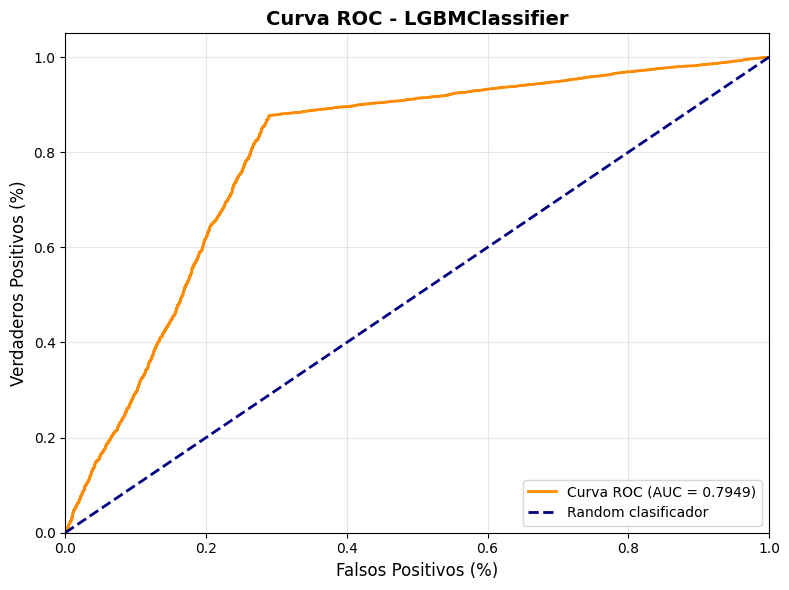

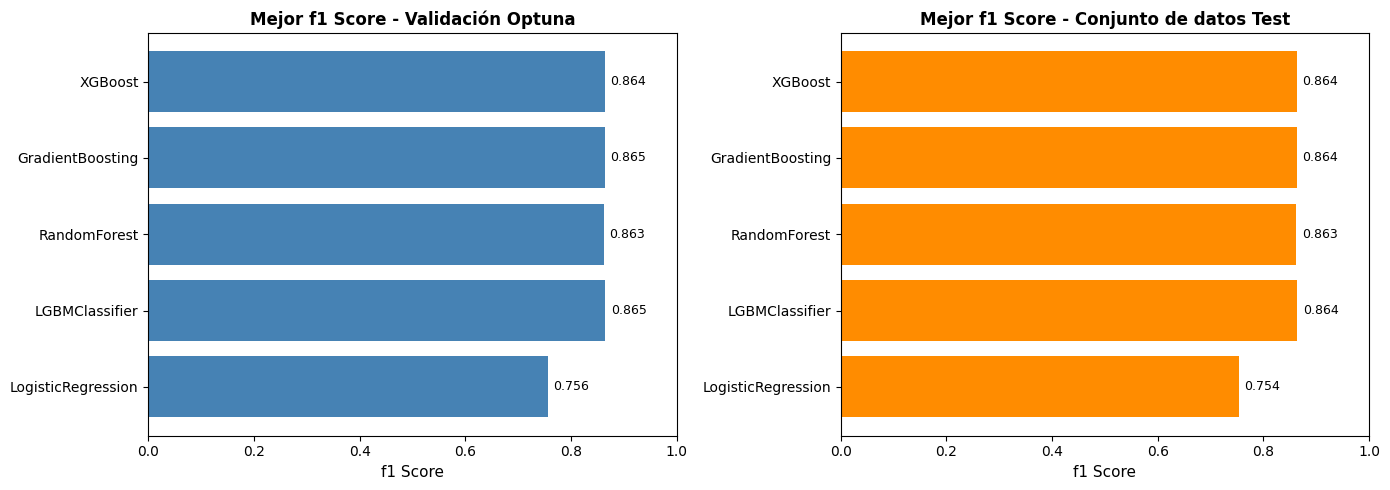

✅ Graficos Optuna - Mejor modelo: LGBMClassifier



📊 Gráficos (EDA)...


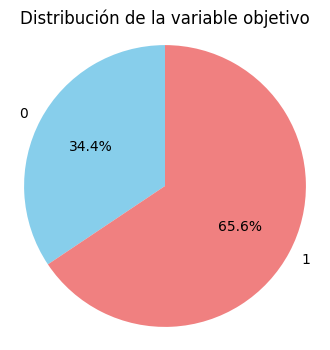

  ⚠️ Error en grafico boxplots: Bin edges must be unique: Index([0.0, 0.0, 1.0, 1.0], dtype='float64', name='churn').
You can drop duplicate edges by setting the 'duplicates' kwarg

✅ Realizado: Registrar el mejor modelo en Unity Catalog.


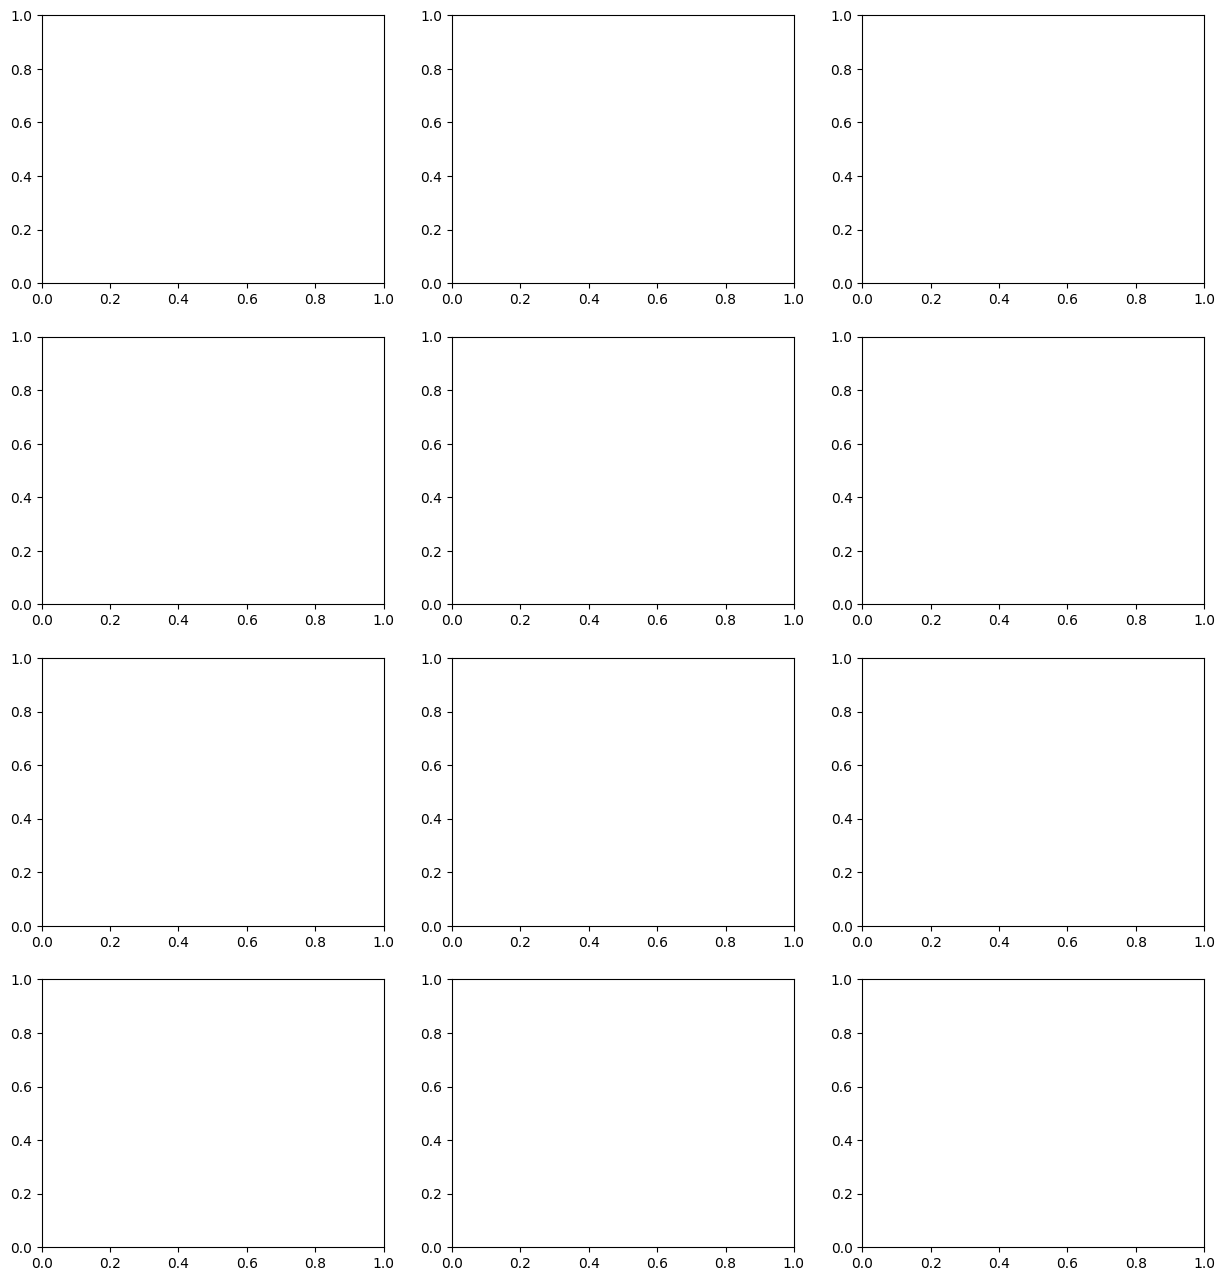

In [0]:
with mlflow.start_run(run_name=f"{run_name}_BEST_{best_model_name}") as run:
    y_pred_best = best_model.predict(X_test)
    y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]
    
    best_metrics = {
        'f1': f1_score(y_test, y_pred_best, pos_label=pos_label),
        'accuracy': accuracy_score(y_test, y_pred_best),
        'precision': precision_score(y_test, y_pred_best, pos_label=pos_label),
        'recall': recall_score(y_test, y_pred_best, pos_label=pos_label),
        'roc_auc': roc_auc_score(y_test, y_pred_proba_best)
    }
    
    # Log parámetros
    mlflow.log_param("model_type", best_model_name)
    mlflow.log_param("best_model", True)
    mlflow.log_param("optimization", "optuna")
    mlflow.log_param("n_trials", n_trials)
    for param, value in best_params[best_model_name].items():
        mlflow.log_param(f"best_{param}", value)
    
    # Log métricas
    for metric_name, metric_value in best_metrics.items():
        mlflow.log_metric(metric_name, metric_value)
    
    signature = infer_signature(X_train_full, y_pred_best)

    # Log modelo con pip conda_env, parace que es mas restringido que pip_requirements
    # model_info = mlflow.sklearn.log_model(best_model, "model", signature=signature, registered_model_name=model_full_name,conda_env=conda_env)

    # Log modelo con pip_requirements (más flexible que conda_env)
    model_info = mlflow.sklearn.log_model(best_model, "model", signature=signature, registered_model_name=model_full_name, pip_requirements=pip_requirements)

    run_id = run.info.run_id
    print(f"\n{'='*80}")
    print("✅ MODELO REGISTRADO EN UNITY CATALOG")
    print(f"{'='*80}")
    print(f"\nModelo: {model_full_name}")
    print(f"Tipo: {best_model_name}")
    print(f"Run_Id: {run.info.run_id}")

    print(f"\nMejores hiperparámetros:")
    for param, value in best_params[best_model_name].items():
        print(f"- {param}: {value}")
    print(f"\nMétricas en test set:")
    for metric_name, metric_value in best_metrics.items():
        print(f"- {metric_name}: {metric_value:.4f}")

    # Seleccionar solo columnas numéricas para los gráficos, Excluir columnas datetime
    X_train_numeric = X_train.select_dtypes(include=['int32', 'int64', 'float64', 'double', 'byte', 'short', 'int'])
    
    print(f"\n📊 Gráficos metricas...")
    try:
        tmp_plot = plot_confusion_matrix(y_test, y_pred, best_model_name, target_col)
        mlflow.log_figure(tmp_plot, "confusion_matrix.png")
    except Exception as e:
        print(f"  ⚠️ Error en grafico matriz de confusion: {e}")

    try:
        tmp_plot = plot_ROC_curve(y_test, y_pred_proba, best_model_name)
        mlflow.log_figure(tmp_plot, "ROC_curve.png")
        display(tmp_plot)
    except Exception as e:
        print(f"  ⚠️ Error en grafico curva ROC: {e}")

    try:
        tmp_plot = plot_compare_scores(optimization_results, best_results, metric_score)
        mlflow.log_figure(tmp_plot, "compare_scores.png")
        display(tmp_plot)
    except Exception as e:
        print(f"  ⚠️ Error en grafico comparación score: {e}")


    print(f"✅ Graficos Optuna - Mejor modelo: {best_model_name}")
    study = next(s['Study'] for s in studies if s['Model'] == best_model_name)

    try:
        tmp_plot = optuna.visualization.plot_optimization_history(study)
        mlflow.log_figure(tmp_plot, "optuna_history.png")
    except Exception as e:
        print(f"  ⚠️ Error en grafico Optuna historia: {e}")

    try:
        tmp_plot = optuna.visualization.plot_param_importances(study)
        mlflow.log_figure(tmp_plot, "optuna_importances.png")
        display(tmp_plot)
    except Exception as e:
        print(f"  ⚠️ Error en grafico Optuna importancia: {e}")

    try:
        tmp_plot = optuna.visualization.plot_slice(study)
        mlflow.log_figure(tmp_plot, "optuna_slice.png")
    except Exception as e:
        print(f"  ⚠️ Error en grafico Optuna slice: {e}")
    
    try:
        tmp_plot = optuna.visualization.plot_parallel_coordinate(study)
        mlflow.log_figure(tmp_plot, "optuna_parallel_coordinate.png")
    except Exception as e:
        print(f"  ⚠️ Error en grafico Optuna parallel_coordinate: {e}")


    print(f"\n📊 Gráficos (EDA)...")

    try:
        tmp_plot = plot_target_distributions(train_pdf, target_col)
        mlflow.log_figure(tmp_plot, "target_distributions.png")
        display(tmp_plot)
    except Exception as e:
        print(f"  ⚠️ Error en grafico distribución variable objetivo: {e}")

    try:
        tmp_plot = plot_feature_distributions(X_train_numeric, y_train)
        mlflow.log_figure(tmp_plot, "feature_distributions.png")
    except Exception as e:
        print(f"  ⚠️ Error en grafico distribuciones de caracterusticas: {e}")
    
    try:
        tmp_plot = plot_correlation_heatmap(X_train_numeric, y_train)
        mlflow.log_figure(tmp_plot, "correlation_heatmap.png")
    except Exception as e:
        print(f"  ⚠️ Error en grafico correlaciones: {e}")
    
    try:
        tmp_plot = plot_feature_target_relationships(X_train_numeric, y_train)
        mlflow.log_figure(tmp_plot, "feature_target_relationships.png")
    except Exception as e:
        print(f"  ⚠️ Error en grafico scatter plots: {e}")
    
    try:
        corr_with_target = X_train_numeric.corrwith(y_train).abs().sort_values(ascending=False)
        top_features = corr_with_target.head(4).index.tolist()
        tmp_plot = plot_pairwise_relationships(X_train_numeric, y_train, top_features)
        mlflow.log_figure(tmp_plot, "pairwise_relationships.png")
    except Exception as e:
        print(f"  ⚠️ Error en grafico pairwise plots: {e}")
    
    try:
        tmp_plot = plot_outliers(X_train_numeric)
        mlflow.log_figure(tmp_plot, "outlier_detection.png")
    except Exception as e:
        print(f"  ⚠️ Error en grafico outliers: {e}")
    
    try:
        tmp_plot = plot_boxplots(X_train_numeric, y_train)
        mlflow.log_figure(tmp_plot, "feature_boxplots_by_target.png")
    except Exception as e:
        print(f"  ⚠️ Error en grafico boxplots: {e}")
    
    mlflow.end_run()
    tmp_plot = None
    print(f"\n✅ Realizado: Registrar el mejor modelo en Unity Catalog.")

## 7. Ultima version del modelo línea base/challenger
- Adicionar descripción modelo, tag y marcar la versión del modelo como `challenger`. Modelos `challenger` son candidatos a remplazar el modelo `Champion` que esta actualmente en uso.
- Utilizamos alias en el modelo para indicar la etapa en el ciclo de vida.

In [0]:
from mlflow.tracking import MlflowClient
mlflow_client = MlflowClient(registry_uri="databricks-uc")

def get_last_model_version(model_name):
    versions = mlflow_client.search_model_versions(f"name='{model_name}'")
    latest = max(versions, key=lambda v: int(v.version))
    return latest

latest_model = get_last_model_version(model_full_name)
runs = mlflow.search_runs(experiment_names=[xp_name], order_by=["start_time DESC", f"metrics.{metric_score} DESC"], max_results=1,
                                filter_string=f"status = 'FINISHED' and run_name LIKE '%{run_name}_BEST_%'")
if runs.empty:
  runs = mlflow.search_runs(experiment_ids=[experiment_id], order_by=["start_time DESC", f"metrics.{metric_score} DESC"], max_results=1,
                            filter_string=f"status='FINISHED' and run_name LIKE '%{run_name}_BEST_%'")

if runs.empty:
  print(f"No se encontraron ejecuciones del experimento, utilizando: mlflow.search_runs()")
  model_uri = f"models:/{model_full_name}/{latest_model.version}"
else:
  run_id = runs.iloc[0]['run_id']
  #model_uri = f"runs:/{run_id}/model"
  model_uri = f"models:/{model_full_name}/{latest_model.version}"

model_desc = f"Predecir probabilidad de abandono de clientes utililiza caracteristicas de las tablas: {feature_table_name}. Metrica para validar modelo: {metric_score}."

mlflow_client.update_registered_model(name=latest_model.name,
  description=model_desc,
)

model_desc = f"{model_desc}. Valor de la metrica de validacion {metric_score}: {round(best_score, 4)*100}%."

mlflow_client.update_model_version(name=latest_model.name, version=latest_model.version, description=model_desc)
mlflow_client.set_model_version_tag(name=latest_model.name, version=latest_model.version, key="best_score", value=f"{round(best_score, 4)}")
mlflow_client.set_registered_model_alias( name=latest_model.name, alias=model_alias_challenger, version=latest_model.version)
print(f"\n✅ Modelo registrado en Unity Catalog: {model_full_name} - {model_alias_challenger}")

2026/05/08 03:12:51 WARNING mlflow.tracking.fluent: Cannot retrieve experiment by name customer_churn_classifier



✅ Modelo registrado en Unity Catalog: medallion_dev.gold.customer_churn_classifier - Challenger


### Ejemplo imprimir datos de matriz de confusion 2x2

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

print(f"\nMétricas matriz de confusión:")
if cm.shape == (2, 2):
    print(f"Verdaderos Negativos: {cm[0,0]}")
    print(f"Falsos Positivos:     {cm[0,1]}")
    print(f"Falsos Negativos:     {cm[1,0]}")
    print(f"Verdaderos Positivos: {cm[1,1]}")
else:
    print(f"Matriz de confusión:\n{cm}")

In [0]:
clean_resouces = False

if clean_resouces:
    try:
        studies = None
        study = None
        del df
        print("borrado: df")
        del train_df
        print("borrado: train_df")
        del test_df
        print("borrado: test_df")
        del train_set
        print("borrado: train_set")
        del test_set
        print("borrado: test_set")
        del X_train
        print("borrado: X_train")
        del y_train
        print("borrado: y_train")
        del X_test
        print("borrado: X_test")
        del y_test
        print("borrado: y_test")
        del X_val
        print("borrado: X_val")
        del train_pdf
        print("borrado: train_pdf")
        del X_train_full
        print("borrado: X_train_full")
        del y_train_full
        print("borrado: y_train_full")
        del y_val
        print("borrado: y_val")
        del y_pred
        print("borrado: y_pred")
        del y_pred_best
        print("borrado: y_pred_best")
    except Exception as e:
        print(f"Error al limpiar recursos: {e}")

    # UNPERSIST TABLE is not supported on serverless compute (df.unpersist(blocking=True))
    try:
        df.unpersist(blocking=True)
        train_df.unpersist(blocking=True)
        test_df.unpersist(blocking=True)
        train_set.unpersist(blocking=True)
        test_set.unpersist(blocking=True)
        X_train.unpersist(blocking=True)
        y_train.unpersist(blocking=True)
        X_test.unpersist(blocking=True)
        y_test.unpersist(blocking=True)
    except:
        pass